In [1]:
import pandas as pd

In [53]:
df = pd.read_csv('../Titanic.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [54]:
cat_cols = ["Survived", "Pclass", "Sex", "Embarked" , "SibSp", "Parch"]
df[cat_cols] = df[cat_cols].astype('category')

In [55]:
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

In [56]:
df.dropna(subset=['Embarked'], inplace=True)

In [57]:
median_age = df['Age'].median()
df['Age'].fillna(median_age, inplace=True)

/tmp/ipykernel_9477/1245384040.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(median_age, inplace=True)


0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 889, dtype: float64

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [58]:
num_cols = df.select_dtypes("number").columns
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3 - q1
    lower_fence = q1 - 1.5 * IQR
    upper_fence = q3 + 1.5 * IQR

    print("=============================================================")
    print("before replacing outliers")
    lower_outliers = df[df[col] < lower_fence][col].values
    upper_outliers = df[df[col] > upper_fence][col].values
    print(f"Column: {col}, Lower Outliers: {len(lower_outliers)}, Upper Outliers: {len(upper_outliers)}")
    print("=============================================================")

    lower_outliers = df[df[col] < lower_fence][col].values
    upper_outliers = df[df[col] > upper_fence][col].values


    df[col] = df[col].replace(lower_outliers, lower_fence)
    df[col] = df[col].replace(upper_outliers, upper_fence)

   
    print("=============================================================")
    print("after replacing outliers")
    lower_outliers = df[df[col] < lower_fence][col].values
    upper_outliers = df[df[col] > upper_fence][col].values
    print(f"Column: {col}, Lower Outliers: {len(lower_outliers)}, Upper Outliers: {len(upper_outliers)}")
    print("=============================================================")

before replacing outliers
Column: Age, Lower Outliers: 0, Upper Outliers: 8
after replacing outliers
Column: Age, Lower Outliers: 0, Upper Outliers: 0
before replacing outliers
Column: Fare, Lower Outliers: 0, Upper Outliers: 114
after replacing outliers
Column: Fare, Lower Outliers: 0, Upper Outliers: 0


In [59]:
df.describe()

,Age,Fare
count,712.000000,889.000000
mean,29.568357,23.956061
std,14.288881,20.414997
min,0.420000,0.000000
25%,20.000000,7.895800
50%,28.000000,14.454200
75%,38.000000,31.000000
max,65.000000,65.656300


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

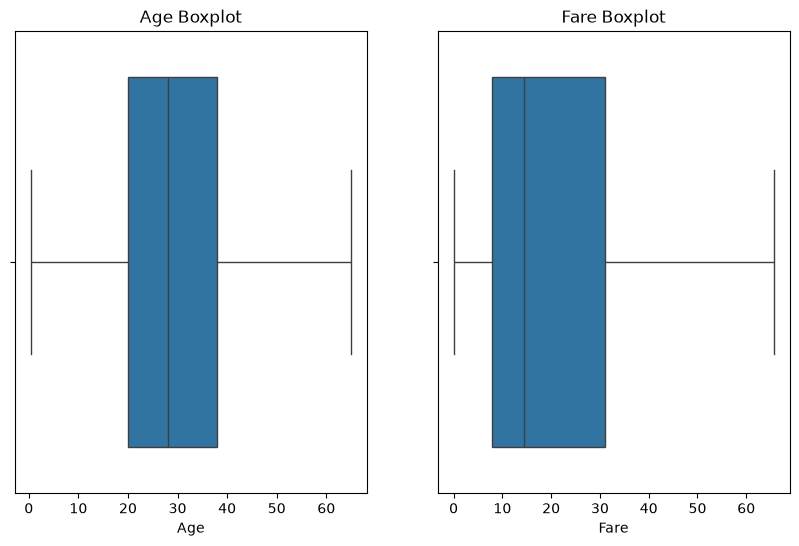

In [63]:
plt.figure(figsize=(10, 6))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(df[col]  , orient = 'h')
    plt.title(f"{col} Boxplot")

In [68]:
def replace_outliers_with_fences(df, num_cols):
    for col in num_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        IQR = q3 - q1
        lower_fence = q1 - 1.5 * IQR
        upper_fence = q3 + 1.5 * IQR
        df[col] = df[col].clip(lower_fence, upper_fence)
    return df

In [69]:
df = replace_outliers_with_fences(df, num_cols)

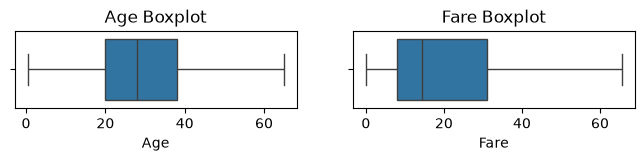

In [71]:
plt.figure(figsize=(8, 1))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(df[col]  , orient = 'h')
    plt.title(f"{col} Boxplot")

In [72]:
def handle_outliers(df, algo = "iqr" , treatment = "mediam" , multiplier = 1.5):
    num_cols = df.select_dtypes("number").columns
    for col in num_cols:
        if algo == "iqr":
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            IQR = q3 - q1
            lower_fence = q1 - multiplier * IQR
            upper_fence = q3 + multiplier * IQR
        elif algo == "zscore":
            mean = df[col].mean()
            std_dev = df[col].std()
            lower_fence = mean - multiplier * std_dev
            upper_fence = mean + multiplier * std_dev
        else:
            raise ValueError("Invalid algorithm specified. Use 'iqr' or 'zscore'.")

        if treatment == "median":
            median_value = df[col].median()
            df[col] = df[col].clip(lower_fence, upper_fence).fillna(median_value)
        elif treatment == "mean":
            mean_value = df[col].mean()
            df[col] = df[col].clip(lower_fence, upper_fence).fillna(mean_value)
        else:
            raise ValueError("Invalid treatment specified. Use 'median' or 'mean'.")
    return df

# Check and handle duplicated

In [78]:
df.duplicated().sum()

np.int64(0)

In [77]:
df.drop_duplicates(inplace=True)

In [79]:
def drop_duplicates(df , duplicate_subset = None , strategy = "first"):
    df = df.drop_duplicates(subset=duplicate_subset, keep=strategy).reset_index(drop=True)
    return df

In [80]:
num_cols

Index(['Age', 'Fare'], dtype='str')

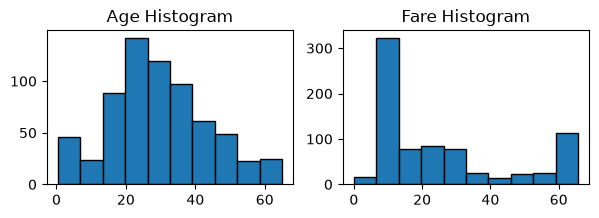

In [83]:
plt.figure(figsize=(7, 2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i + 1)
    plt.hist(df[col] , edgecolor='black')
    plt.title(f"{col} Histogram")
  

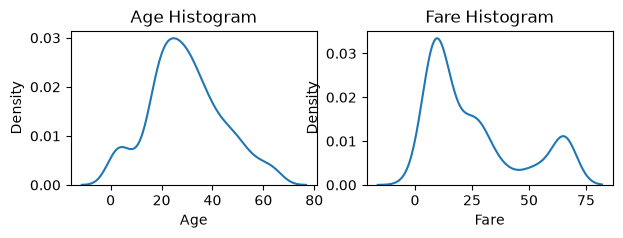

In [84]:
plt.figure(figsize=(7, 2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i + 1)
    sns.kdeplot(df[col])
    plt.title(f"{col} Histogram")
  

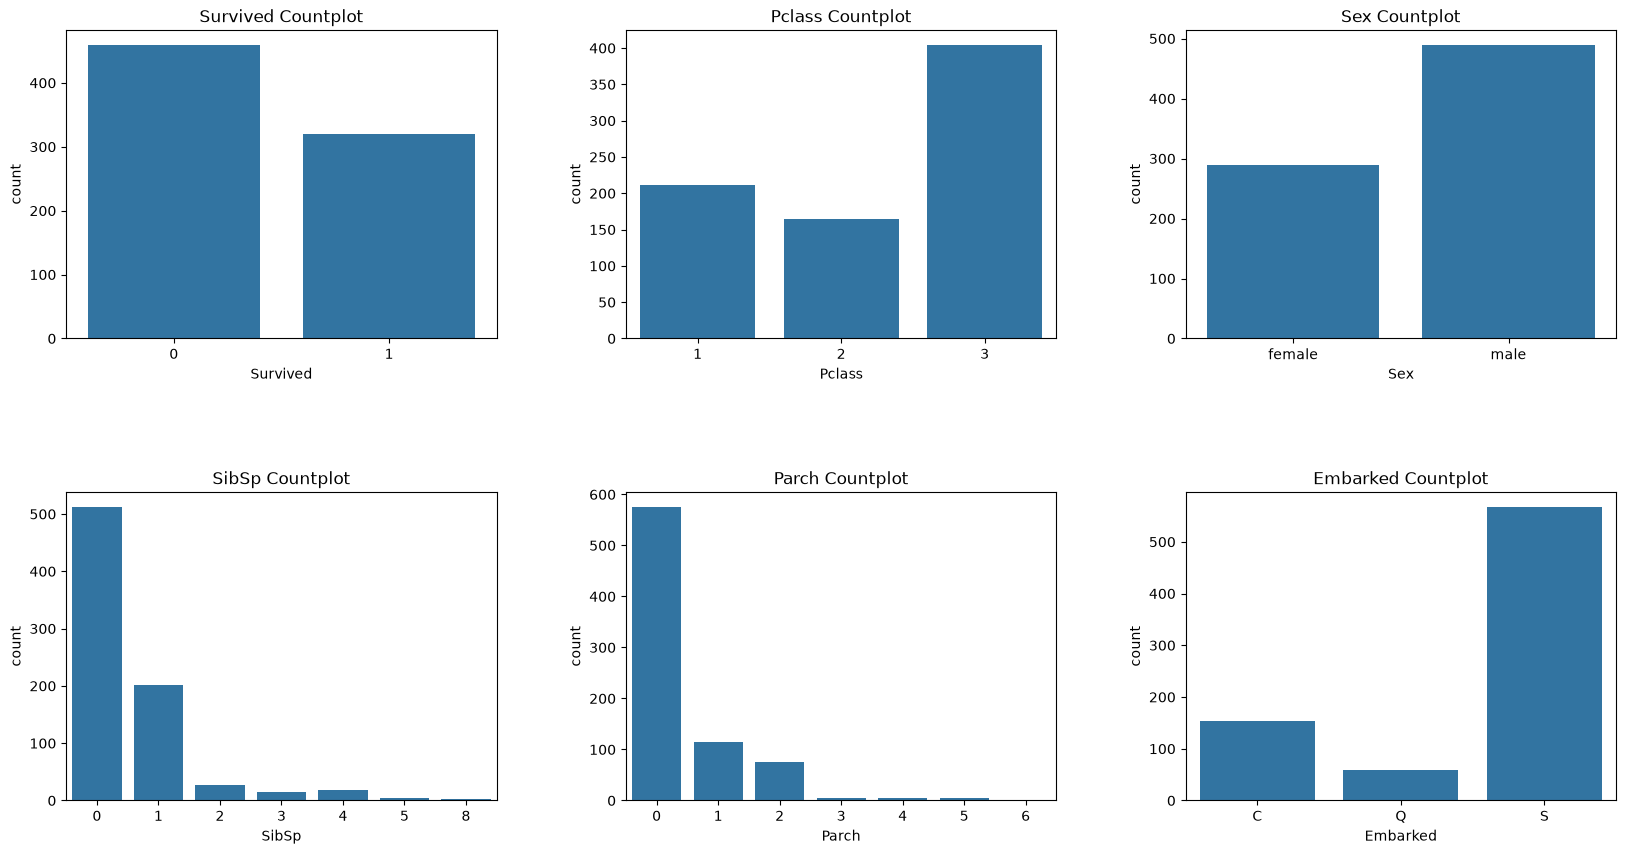

In [102]:
cat_cols = df.select_dtypes("category").columns
plt.figure(figsize=(20, 10))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=col, data=df)
    plt.title(f"{col} Countplot")
plt.subplots_adjust(hspace=0.5, wspace=0.3)    

In [ ]:
#value_counts() counts how many times each unique value appears.
# It returns a Series with the counts of each unique value.
# for example, if you have a column "Survived" with values 0 and 1, value_counts() will return the count of how many times 0 and 1 appear in that column.
unique = df["Survived"].value_counts()
counts = unique.values
categories = unique.index
categories

CategoricalIndex([0, 1], categories=[0, 1], ordered=False, dtype='category', name='Survived')

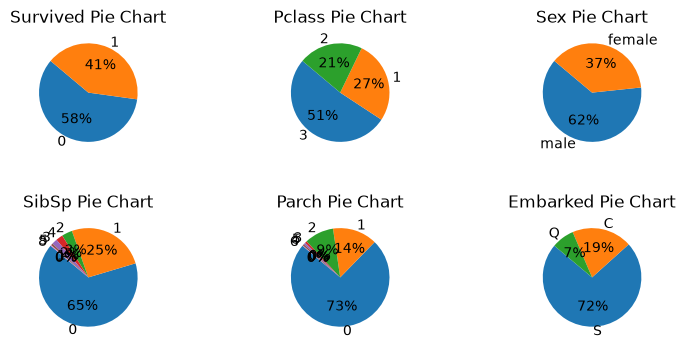

In [110]:
plt.figure(figsize=(9, 4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1)
    unique = df[col].value_counts()
    counts = unique.values
    categories = unique.index
    plt.pie(counts, labels=categories, startangle=140, autopct='%1.1d%%')
    plt.title(f"{col} Pie Chart")
plt.subplots_adjust(hspace=0.5, wspace=0.3)    

## few rules
If the relationship is between num and num : 
- scatter plot
- pair plot
- line plot
- Heatmap plot
---
If the relationship is between cat and num :  
- bar plot
---
If the relationship is between cat and cat : 
- Heatmap



Text(0, 0.5, 'Fare')

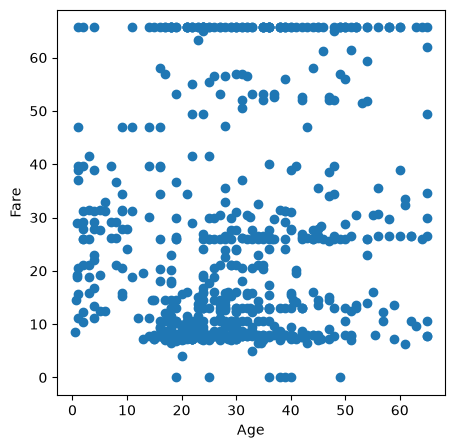

In [114]:
plt.figure(figsize=(5, 5))
plt.scatter(df['Age'], df['Fare'])
plt.xlabel('Age')
plt.ylabel('Fare')

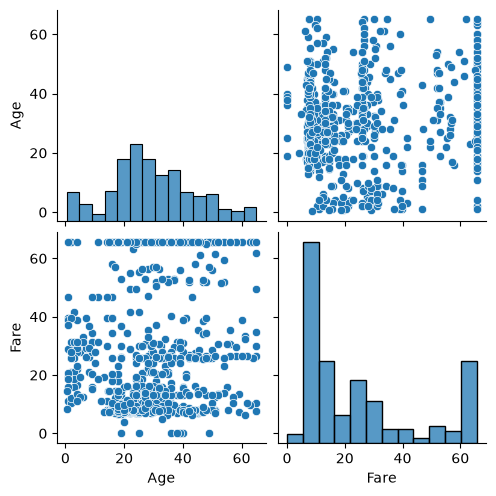

In [116]:
sns.pairplot(df[["Age", "Fare"]])

In [119]:
corr = df.corr(numeric_only=True)
corr

,Age,Fare
Age,1.000000,0.151381
Fare,0.151381,1.000000


<Axes: >

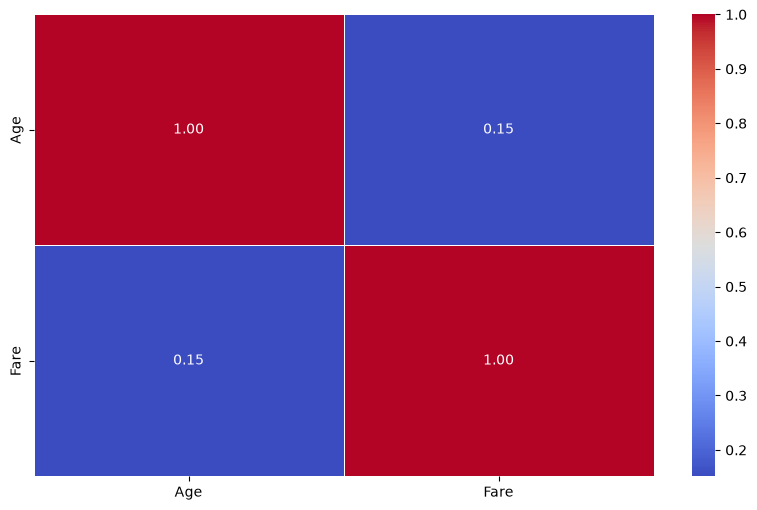

In [120]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)